# Baseline: FedAvg + LoRA on AG News

## Research Question
> *Foundation models are too large to fine-tune on edge devices, so we use LoRA to restrict updates to a tiny low-rank subspace. However, a single global LoRA fails under Non-IID user data. Our approach adds client-specific weight-masking inside the LoRA module: each user discovers and trains only a sparse subnetwork — a personalized "lottery ticket" — within the shared LoRA. This yields a global collaborative core while giving every client their own sparse personalized identity, all without uploading private data or full adapter weights.*

## Baseline Design
| Component | Choice | Reason |
|-----------|--------|--------|
| **Dataset** | AG News (4-class) | Clear class-based client identities; lightweight; standard FL+PEFT benchmark |
| **Model** | DistilBERT + LoRA | Small, fast; LoRA is SOTA PEFT for FL (FedPETuning, FFA-LoRA) |
| **Aggregation** | FedAvg (constant) | Tweak only the *communication* policy, not aggregation |
| **Non-IID** | Per-class skew (dominant_ratio=0.8) | Realistic user preference heterogeneity |


This is a faithful, reproducible implementation of the standard FedAvg + LoRA baseline.  
It can be easily extended later to FedAvg + Masked LoRA (proposed method).

## Section 1: Imports

In [1]:
!pip install -q peft datasets evaluate accelerate

import textwrap
import torch
from IPython.display import display, HTML
import html
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from tqdm import tqdm
from copy import deepcopy
from transformers import AutoTokenizer

import warnings
import logging

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
Device: cuda


In [2]:
CONFIG = {
    'num_clients': 4,
    'class_names': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'dominant_ratio': 0.80,
    'n_train': 2000, # 2000
    'n_test': 500, # 500
    'n_global_test': 400, # 400
    'model_name': 'distilbert-base-uncased',
    'num_labels': 4,
    'max_length': 128,
    'lora_r': 8,
    'lora_alpha': 16,
    'lora_dropout': 0.1,
    'target_modules': ['q_lin', 'v_lin'],
    'num_rounds': 30, # 30
    'local_epochs': 2, # 2 standard in FL + PEFT papers 
    'batch_size': 32,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'device': device,
    'seed': SEED,

    'bits_per_param': 32,  # float32
    'num_local_epochs': 5
}

In [3]:
CONFIG['personalization_steps'] = CONFIG['n_train'] // CONFIG['batch_size']

In [4]:
# Suppressing WARNINGS - VERY IMPORTANT 

warnings.filterwarnings("ignore", message=".*UNEXPECTED.*")
warnings.filterwarnings("ignore", message=".*MISSING.*")

## Section 2: Dataset & Non-IID Client Partitioning

**AG News** has 4 classes mapped directly to 4 clients:
- Client 1 → **World** news (80% World, 20% other)
- Client 2 → **Sports** (80% Sports, 20% other)
- Client 3 → **Business** (80% Business, 20% other)
- Client 4 → **Sci/Tech** (80% Sci/Tech, 20% other)

This matches the label-skew non-IID setup from FedPETuning and pFedLoRA.

In [5]:
dataset = load_dataset("ag_news")
print(f"Train: {len(dataset['train']):,} | Test: {len(dataset['test']):,}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 120,000 | Test: 7,600


In [6]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=CONFIG['max_length'])

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [7]:
def show_tokenization_demo(text, max_len=32):
    enc = tokenizer(text, truncation=True, max_length=max_len)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"])

    print("="*70)
    print("TEXT:", text)
    print("\nTOKENS:")
    print(tokens)
    print("\nTOKEN COUNT:", len(tokens))
    print("\nDECODED BACK:")
    print(tokenizer.decode(enc["input_ids"]))
    print("="*70)

show_tokenization_demo("Google stock rises after strong earnings report.", max_len=32)
show_tokenization_demo("Manchester United wins dramatic match in extra time.", max_len=32)

TEXT: Google stock rises after strong earnings report.

TOKENS:
['[CLS]', 'google', 'stock', 'rises', 'after', 'strong', 'earnings', 'report', '.', '[SEP]']

TOKEN COUNT: 10

DECODED BACK:
[CLS] google stock rises after strong earnings report. [SEP]
TEXT: Manchester United wins dramatic match in extra time.

TOKENS:
['[CLS]', 'manchester', 'united', 'wins', 'dramatic', 'match', 'in', 'extra', 'time', '.', '[SEP]']

TOKEN COUNT: 11

DECODED BACK:
[CLS] manchester united wins dramatic match in extra time. [SEP]


In [8]:
def create_noniid_splits(split, num_clients, n_samples, dominant_ratio=0.8):
    labels = np.array(split['labels'])
    class_idx = {c: np.where(labels == c)[0] for c in range(num_clients)}
    client_indices = []
    rng = np.random.default_rng(CONFIG['seed'])
    for cid in range(num_clients):
        n_dom = int(n_samples * dominant_ratio)
        n_oth = (n_samples - n_dom) // (num_clients - 1)
        dom = rng.choice(class_idx[cid], min(n_dom, len(class_idx[cid])), replace=False)
        oth = []
        for c in range(num_clients):
            if c != cid:
                oth.extend(rng.choice(class_idx[c], min(n_oth, len(class_idx[c])), replace=False).tolist())
        idx = np.concatenate([dom, np.array(oth)])
        rng.shuffle(idx)
        client_indices.append(idx[:n_samples])
    return client_indices

train_idx = create_noniid_splits(tokenized['train'], CONFIG['num_clients'], CONFIG['n_train'])
test_idx  = create_noniid_splits(tokenized['test'],  CONFIG['num_clients'], CONFIG['n_test'])

test_labels = np.array(tokenized['test']['labels'])
global_test_idx = np.concatenate([
    np.where(test_labels == c)[0][:CONFIG['n_global_test']] for c in range(4)
])

print("Non-IID partitioning completed.")
print(f"Global test set size: {len(global_test_idx)} samples (balanced)")

Non-IID partitioning completed.
Global test set size: 1600 samples (balanced)


In [9]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'], num_labels=CONFIG['num_labels']
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=CONFIG['lora_r'],
    lora_alpha=CONFIG['lora_alpha'],
    lora_dropout=CONFIG['lora_dropout'],
    target_modules=CONFIG['target_modules']
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


## Section 3: DataLoaders & Model Factory

In [10]:
collator = DataCollatorWithPadding(tokenizer)

def make_loader(split, indices, batch_size, shuffle=True):
    subset = split.select(indices.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, collate_fn=collator)

client_train_loaders = [make_loader(tokenized['train'], idx, CONFIG['batch_size']) for idx in train_idx]
client_test_loaders  = [make_loader(tokenized['test'],  idx, CONFIG['batch_size'], False) for idx in test_idx]
global_test_loader   = make_loader(tokenized['test'], global_test_idx, CONFIG['batch_size'], False)

print(f"Global test set: {len(global_test_idx)} samples")

Global test set: 1600 samples


## Section 4: Training and Evaluation

In [11]:
# Sparsity Utility

def compute_sparsity(model):
    """
    Returns fraction of near-zero LoRA parameters.
    Baseline will always return approximately 0.0.
    Msked method will return 0.4–0.7.
    That contrast IS our communication efficiency claim.
    """
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if 'lora_' in name:
            total += param.numel()
            zeros += (param.abs() < 1e-6).sum().item()
    return zeros / total if total > 0 else 0.0


def count_lora_parameters(model):
    count = 0
    for name, param in model.named_parameters():
        if 'lora_' in name and param.requires_grad:
            count += param.numel()
    return count


def bytes_per_round(model, num_clients, sparsity=0.0):
    """
    Upload + download cost per round in bytes.
    sparsity=0.0 for baseline (sends all params).
    Method passes actual sparsity to show reduction.
    """
    lora_params = count_lora_parameters(model)
    active_params = int(lora_params * (1 - sparsity))
    bytes_per_client = active_params * (CONFIG['bits_per_param'] // 8)
    # Each client uploads once, global model downloads to all clients
    upload = bytes_per_client * num_clients
    download = bytes_per_client * num_clients
    return upload + download

In [12]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total += batch['labels'].size(0)
    return correct / total if total > 0 else 0.0

In [13]:

print("=" * 60)
print("PHASE 1: Local-Only Baseline (No Federation)")
print("=" * 60)

local_only_accs = []

for cid in range(CONFIG['num_clients']):
    print(f"\nTraining local-only model for Client {cid+1} ({CONFIG['class_names'][cid]})...")

    lo_base = AutoModelForSequenceClassification.from_pretrained(
        CONFIG['model_name'], num_labels=CONFIG['num_labels']
    )
    lo_model = get_peft_model(lo_base, lora_config).to(device)
    lo_optimizer = AdamW(lo_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

    total_local_epochs = CONFIG['num_local_epochs']
    lo_model.train()
    for ep in range(total_local_epochs):
        for batch in client_train_loaders[cid]:
            batch = {k: v.to(device) for k, v in batch.items()}
            loss = lo_model(**batch).loss
            lo_optimizer.zero_grad()
            loss.backward()
            clip_grad_norm_(lo_model.parameters(), max_norm=1.0)
            lo_optimizer.step()

    acc = evaluate_model(lo_model, client_test_loaders[cid])
    local_only_accs.append(acc)
    print(f"  Client {cid+1} Local-Only Accuracy: {acc:.4f}")

    del lo_model, lo_base
    torch.cuda.empty_cache()

print(f"\nAverage Local-Only Accuracy: {np.mean(local_only_accs):.4f}")
print("This is the personalization upper bound — federation should approach this per client.")

PHASE 1: Local-Only Baseline (No Federation)

Training local-only model for Client 1 (World)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Client 1 Local-Only Accuracy: 0.8938

Training local-only model for Client 2 (Sports)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Client 3 Local-Only Accuracy: 0.9218

Training local-only model for Client 4 (Sci/Tech)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Client 4 Local-Only Accuracy: 0.9459

Average Local-Only Accuracy: 0.9304
This is the personalization upper bound — federation should approach this per client.


In [14]:

training_losses = []   # ← Added to track loss

print("=" * 60)
print("PHASE 2: FedAvg + LoRA (Federated Training)")
print("=" * 60)

global_model = model.to(device)

# --- Tracking ---
training_losses       = []
round_global_accs     = []
round_local_accs      = [[] for _ in range(CONFIG['num_clients'])]
round_comm_cost_mb    = []   # per-round cost
cumulative_comm_mb    = [0.0]  # cumulative, starting at 0

for round_idx in range(CONFIG['num_rounds']):
    print(f"\nRound {round_idx+1}/{CONFIG['num_rounds']}")

    client_updates = []
    round_loss = 0.0
    num_batches = 0

    for client_id in range(CONFIG['num_clients']):
        client_base = AutoModelForSequenceClassification.from_pretrained(
            CONFIG['model_name'], num_labels=CONFIG['num_labels']
        )
        client_model = get_peft_model(client_base, lora_config).to(device)
        client_model.load_state_dict(global_model.state_dict(), strict=False)

        optimizer = AdamW(client_model.parameters(),
                          lr=CONFIG['lr'],
                          weight_decay=CONFIG['weight_decay'])

        client_model.train()
        for epoch in range(CONFIG['local_epochs']):
            for batch in client_train_loaders[client_id]:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = client_model(**batch)
                loss = outputs.loss
                optimizer.zero_grad()
                loss.backward()
                clip_grad_norm_(client_model.parameters(), max_norm=1.0)
                optimizer.step()
                round_loss += loss.item()
                num_batches += 1

        update = {k: v.detach().cpu() for k, v in client_model.state_dict().items() 
          if "lora_" in k 
          or "classifier" in k 
          or "pre_classifier" in k}
        client_updates.append(update)

        del client_model, client_base
        torch.cuda.empty_cache()

    # --- FedAvg Aggregation ---
    if client_updates:
        avg_update = {}
        for key in client_updates[0].keys():
            avg_update[key] = torch.stack([u[key] for u in client_updates]).mean(dim=0)
        global_state = global_model.state_dict()
        global_state.update(avg_update)
        global_model.load_state_dict(global_state)

    # --- Loss ---
    avg_loss = round_loss / num_batches if num_batches > 0 else 0.0
    training_losses.append(avg_loss)

    # --- Communication Cost This Round ---
    # Baseline sparsity = 0.0 (full LoRA params uploaded)
    round_bytes = bytes_per_round(global_model, CONFIG['num_clients'], sparsity=0.0)
    round_mb    = round_bytes / (1024 * 1024)
    round_comm_cost_mb.append(round_mb)
    cumulative_comm_mb.append(cumulative_comm_mb[-1] + round_mb)

    # --- Per-Round Accuracy ---
    g_acc = evaluate_model(global_model, global_test_loader)
    round_global_accs.append(g_acc)

    for cid in range(CONFIG['num_clients']):
        l_acc = evaluate_model(global_model, client_test_loaders[cid])
        round_local_accs[cid].append(l_acc)

    print(f"  Avg Loss: {avg_loss:.4f} | Global Acc: {g_acc:.4f} | Comm This Round: {round_mb:.2f} MB | Cumulative: {cumulative_comm_mb[-1]:.2f} MB")

print("\nFederated training complete.")

PHASE 2: FedAvg + LoRA (Federated Training)

Round 1/30


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Avg Loss: 0.0327 | Global Acc: 0.9006 | Comm This Round: 4.50 MB | Cumulative: 135.00 MB

Federated training complete.



=== Final Evaluation ===
Global Accuracy: 0.9006
Client 1 (World) Local Accuracy: 0.9098
Client 2 (Sports) Local Accuracy: 0.9499
Client 3 (Business) Local Accuracy: 0.8798
Client 4 (Sci/Tech) Local Accuracy: 0.8778

Average Local Accuracy: 0.9043


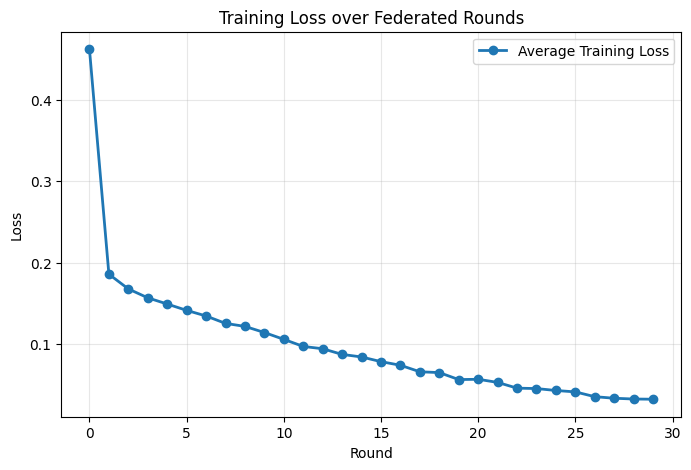

In [15]:
# def evaluate_model(model, dataloader):
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for batch in dataloader:
#             batch = {k: v.to(device) for k, v in batch.items()}
#             outputs = model(**batch)
#             preds = outputs.logits.argmax(dim=-1)
#             correct += (preds == batch['labels']).sum().item()
#             total += batch['labels'].size(0)
#     return correct / total if total > 0 else 0.0

print("\n=== Final Evaluation ===")

global_acc = evaluate_model(global_model, global_test_loader)
print(f"Global Accuracy: {global_acc:.4f}")

local_accs = []
for cid in range(CONFIG['num_clients']):
    local_acc = evaluate_model(global_model, client_test_loaders[cid])
    local_accs.append(local_acc)
    print(f"Client {cid+1} ({CONFIG['class_names'][cid]}) Local Accuracy: {local_acc:.4f}")

print(f"\nAverage Local Accuracy: {np.mean(local_accs):.4f}")

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(training_losses, marker='o', linewidth=2, label='Average Training Loss')
plt.title('Training Loss over Federated Rounds')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
print("=" * 60)
print("PHASE 3: Personalized Accuracy (K-step Local Fine-Tuning)")
print("=" * 60)

def evaluate_personalized(global_model, train_loader, test_loader, device, k_steps=10):
    """
    Take global model, fine-tune for K steps on client's local data,
    evaluate on client's local test set.
    This is the standard personalization evaluation in pFedLoRA, Per-FedAvg, Ditto.
    """
    local_model = deepcopy(global_model).to(device)
    optimizer = AdamW(local_model.parameters(), lr=CONFIG['lr'])

    local_model.train()
    steps = 0
    for batch in train_loader:
        if steps >= k_steps:
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = local_model(**batch).loss
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(local_model.parameters(), max_norm=1.0)
        optimizer.step()
        steps += 1

    acc = evaluate_model(local_model, test_loader)
    del local_model
    torch.cuda.empty_cache()
    return acc


personalized_accs = []
for cid in range(CONFIG['num_clients']):
    p_acc = evaluate_personalized(
        global_model,
        client_train_loaders[cid],
        client_test_loaders[cid],
        device,
        k_steps=CONFIG['personalization_steps']
    )
    personalized_accs.append(p_acc)
    print(f"  Client {cid+1} ({CONFIG['class_names'][cid]}) Personalized Acc: {p_acc:.4f}")

print(f"\nAverage Personalized Accuracy: {np.mean(personalized_accs):.4f}")

PHASE 3: Personalized Accuracy (K-step Local Fine-Tuning)
  Client 1 (World) Personalized Acc: 0.9379
  Client 2 (Sports) Personalized Acc: 0.9619
  Client 3 (Business) Personalized Acc: 0.9299
  Client 4 (Sci/Tech) Personalized Acc: 0.9399

Average Personalized Accuracy: 0.9424


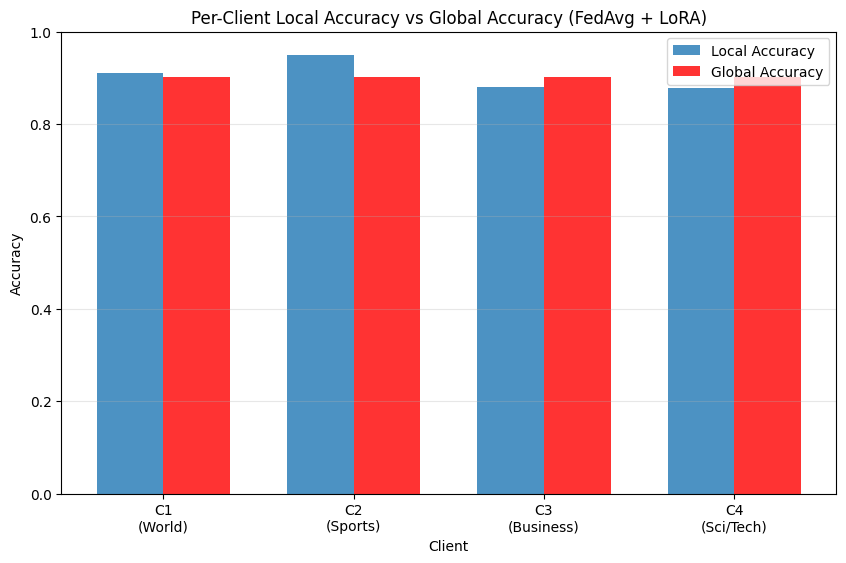

In [17]:
plt.figure(figsize=(10, 6))
x = np.arange(CONFIG['num_clients'])
width = 0.35

plt.bar(x - width/2, local_accs, width, label='Local Accuracy', alpha=0.8)
plt.bar(x + width/2, [global_acc]*CONFIG['num_clients'], width, label='Global Accuracy', alpha=0.8, color='red')

plt.xlabel('Client')
plt.ylabel('Accuracy')
plt.title('Per-Client Local Accuracy vs Global Accuracy (FedAvg + LoRA)')
plt.xticks(x, [f"C{i+1}\n({CONFIG['class_names'][i]})" for i in range(CONFIG['num_clients'])])
plt.legend()
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.show()

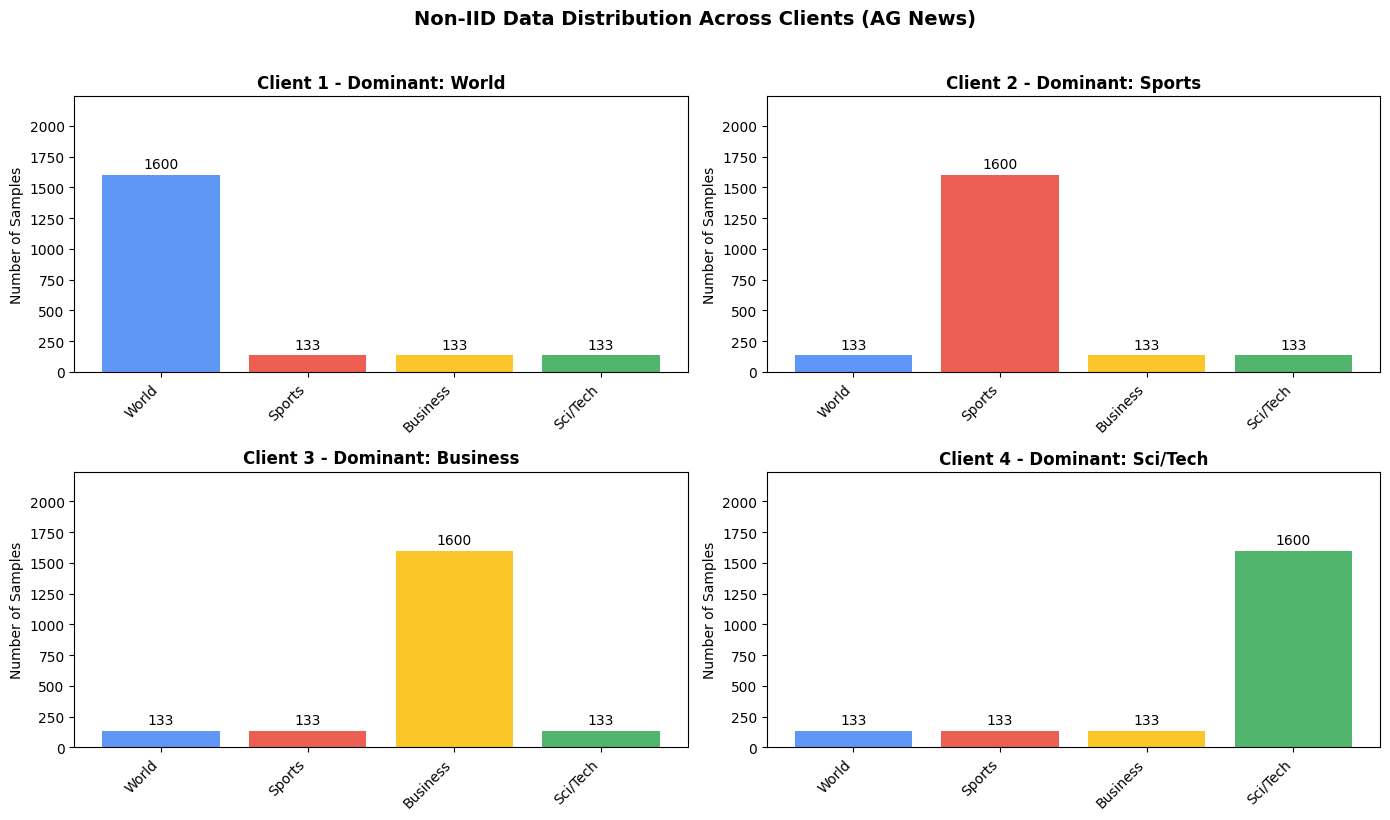

In [18]:
# === Client-wise Class Distribution ===
plt.figure(figsize=(14, 8))
colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']

for i in range(CONFIG['num_clients']):
    lbs = np.array(tokenized['train']['labels'])[train_idx[i]]
    counts = [np.sum(lbs == c) for c in range(4)]
    
    plt.subplot(2, 2, i+1)
    bars = plt.bar(CONFIG['class_names'], counts, color=colors, alpha=0.85)
    plt.title(f"Client {i+1} - Dominant: {CONFIG['class_names'][i]}", 
              fontsize=12, fontweight='bold')
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, CONFIG['n_train'] * 1.12)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 30,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.suptitle("Non-IID Data Distribution Across Clients (AG News)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# === Communication Cost Analysis ===
def count_lora_parameters(model):
    count = 0
    for name, param in model.named_parameters():
        if "lora_" in name and param.requires_grad:
            count += param.numel()
    return count

lora_params = count_lora_parameters(global_model)
bytes_per_client = lora_params * 4   # float32 = 4 bytes
total_bytes_per_round = bytes_per_client * CONFIG['num_clients']

print("\n=== Communication Cost (FedAvg + LoRA) ===")
print(f"LoRA parameters per client: {lora_params:,}")
print(f"Bytes sent per client per round: {bytes_per_client:,} bytes")
print(f"Total bytes per round ({CONFIG['num_clients']} clients): {total_bytes_per_round:,} bytes")
print(f"Approximate MB per round: {total_bytes_per_round / (1024*1024):.2f} MB")


=== Communication Cost (FedAvg + LoRA) ===
LoRA parameters per client: 147,456
Bytes sent per client per round: 589,824 bytes
Total bytes per round (4 clients): 2,359,296 bytes
Approximate MB per round: 2.25 MB


### PLOTS & GRAPHS

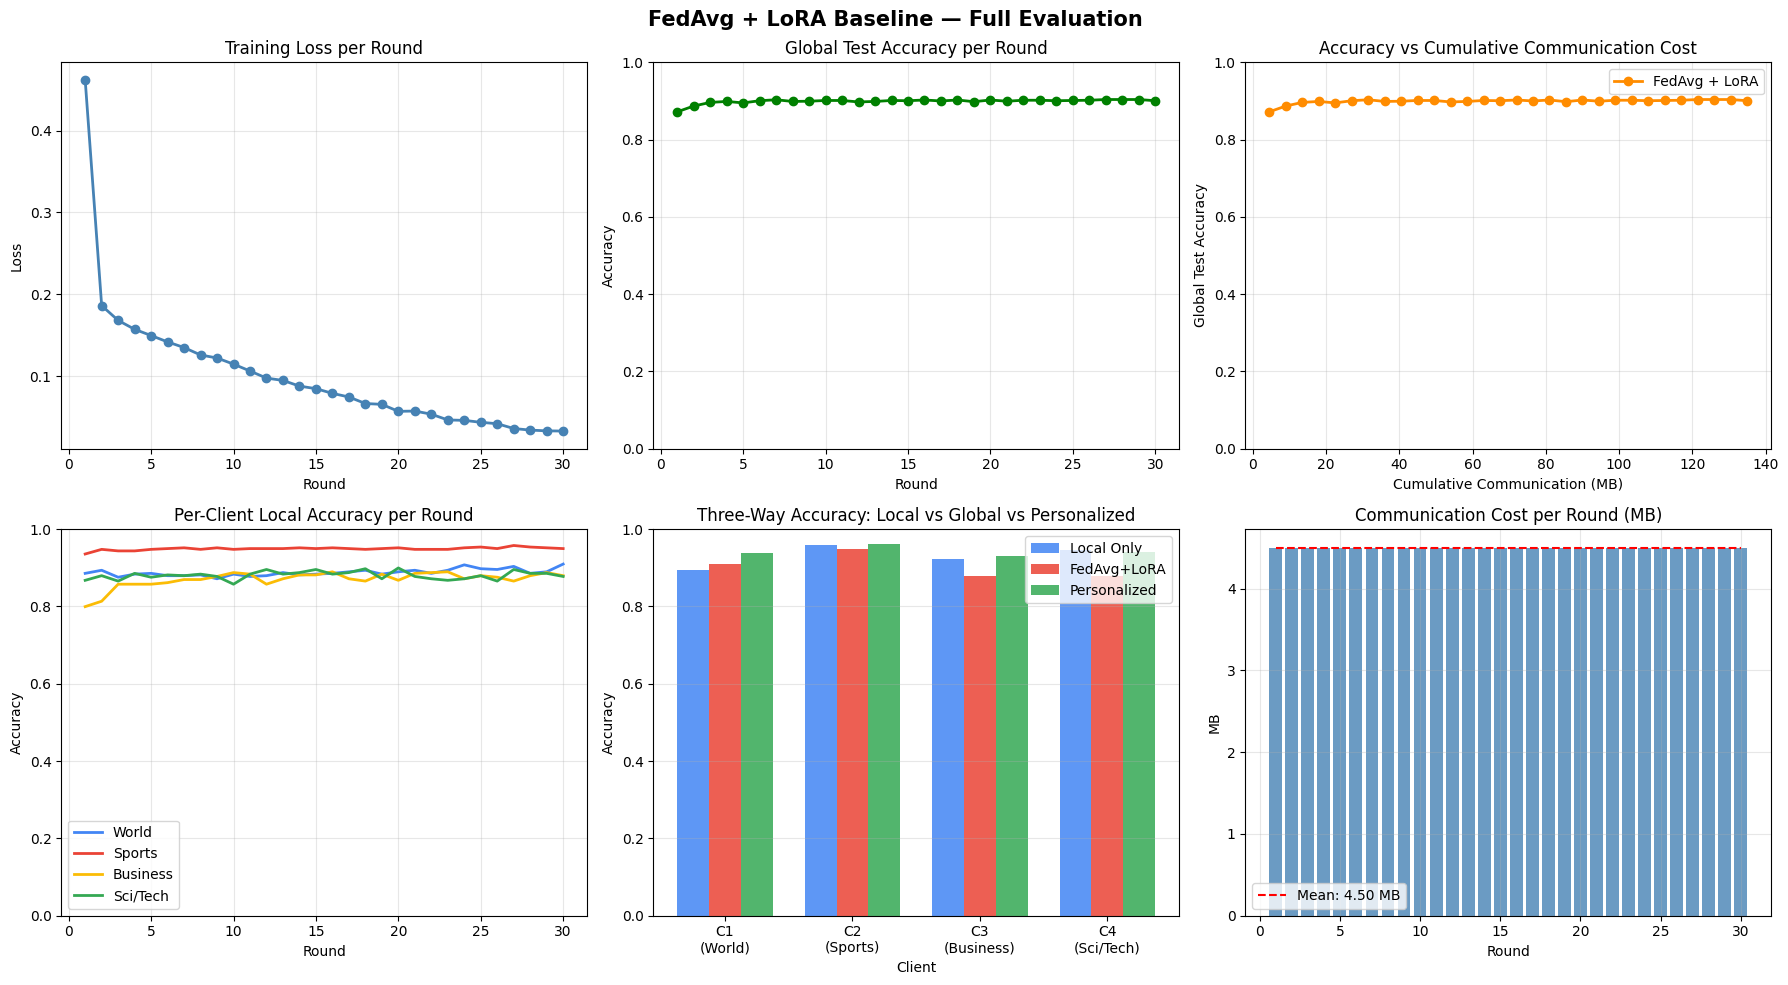

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('FedAvg + LoRA Baseline — Full Evaluation', fontsize=15, fontweight='bold')

rounds = list(range(1, CONFIG['num_rounds'] + 1))

# --- Plot 1: Training Loss ---
axes[0, 0].plot(rounds, training_losses, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Training Loss per Round')
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot 2: Global Accuracy per Round ---
axes[0, 1].plot(rounds, round_global_accs, marker='o', linewidth=2, color='green')
axes[0, 1].set_title('Global Test Accuracy per Round')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].grid(True, alpha=0.3)

# --- Plot 3: Accuracy vs Cumulative Communication Cost ---
# THIS is the standard FL efficiency plot
axes[0, 2].plot(
    cumulative_comm_mb[1:],  # skip the 0 at index 0
    round_global_accs,
    marker='o', linewidth=2, color='darkorange', label='FedAvg + LoRA'
)
axes[0, 2].set_title('Accuracy vs Cumulative Communication Cost')
axes[0, 2].set_xlabel('Cumulative Communication (MB)')
axes[0, 2].set_ylabel('Global Test Accuracy')
axes[0, 2].set_ylim(0, 1.0)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
# NOTE: When you add your masked method, plot it on the same axes.
# Your method should reach the same accuracy at lower cumulative MB.

# --- Plot 4: Per-Client Accuracy per Round ---
colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']
for cid in range(CONFIG['num_clients']):
    axes[1, 0].plot(rounds, round_local_accs[cid],
                    label=CONFIG['class_names'][cid],
                    color=colors[cid], linewidth=2)
axes[1, 0].set_title('Per-Client Local Accuracy per Round')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 5: Three-way Accuracy Comparison ---
global_accs_final  = [round_local_accs[cid][-1] for cid in range(CONFIG['num_clients'])]
x = np.arange(CONFIG['num_clients'])
width = 0.25

axes[1, 1].bar(x - width, local_only_accs,       width, label='Local Only',     alpha=0.85, color='#4285F4')
axes[1, 1].bar(x,          global_accs_final,     width, label='FedAvg+LoRA',    alpha=0.85, color='#EA4335')
axes[1, 1].bar(x + width,  personalized_accs,     width, label='Personalized',   alpha=0.85, color='#34A853')
axes[1, 1].set_title('Three-Way Accuracy: Local vs Global vs Personalized')
axes[1, 1].set_xlabel('Client')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f"C{i+1}\n({CONFIG['class_names'][i]})" for i in range(CONFIG['num_clients'])])
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# --- Plot 6: Communication Cost per Round ---
axes[1, 2].bar(rounds, round_comm_cost_mb, color='steelblue', alpha=0.8)
axes[1, 2].plot(rounds, [np.mean(round_comm_cost_mb)] * len(rounds),
                'r--', label=f'Mean: {np.mean(round_comm_cost_mb):.2f} MB')
axes[1, 2].set_title('Communication Cost per Round (MB)')
axes[1, 2].set_xlabel('Round')
axes[1, 2].set_ylabel('MB')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### FINAL SUMMARY TABLE

In [21]:
print("\n" + "=" * 65)
print("FINAL SUMMARY TABLE")
print("=" * 65)
print(f"{'Client':<12} {'Local-Only':>12} {'FedAvg+LoRA':>13} {'Personalized':>14}")
print("-" * 65)
for cid in range(CONFIG['num_clients']):
    name   = CONFIG['class_names'][cid]
    lo     = local_only_accs[cid]
    fed    = round_local_accs[cid][-1]
    pers   = personalized_accs[cid]
    print(f"C{cid+1} {name:<10} {lo:>12.4f} {fed:>13.4f} {pers:>14.4f}")
print("-" * 65)
print(f"{'Average':<12} {np.mean(local_only_accs):>12.4f} {np.mean(global_accs_final):>13.4f} {np.mean(personalized_accs):>14.4f}")

lora_params = count_lora_parameters(global_model)
total_comm  = cumulative_comm_mb[-1]
print(f"\nLoRA params per client : {lora_params:,}")
print(f"Total communication    : {total_comm:.2f} MB over {CONFIG['num_rounds']} rounds")
print(f"Avg per round          : {np.mean(round_comm_cost_mb):.2f} MB")
print(f"Baseline sparsity      : 0.00% (all LoRA params uploaded)")
print("=" * 65)
print("\nNOTE: Masked LoRA method should show:")
print("  - Same or better Personalized Accuracy")
print("  - Lower Total Communication MB")
print("  - Sparsity > 0% (only active subnet uploaded)")


FINAL SUMMARY TABLE
Client         Local-Only   FedAvg+LoRA   Personalized
-----------------------------------------------------------------
C1 World            0.8938        0.9098         0.9379
C2 Sports           0.9599        0.9499         0.9619
C3 Business         0.9218        0.8798         0.9299
C4 Sci/Tech         0.9459        0.8778         0.9399
-----------------------------------------------------------------
Average            0.9304        0.9043         0.9424

LoRA params per client : 147,456
Total communication    : 135.00 MB over 30 rounds
Avg per round          : 4.50 MB
Baseline sparsity      : 0.00% (all LoRA params uploaded)

NOTE: Masked LoRA method should show:
  - Same or better Personalized Accuracy
  - Lower Total Communication MB
  - Sparsity > 0% (only active subnet uploaded)


In [22]:
# After final evaluation, add this:
print("\n=== Global Balanced Test Accuracy ===")
local_only_global  = []
fedavg_global      = evaluate_model(global_model, global_test_loader)

for cid in range(CONFIG['num_clients']):
    # Re-evaluate local-only models on global test
    # (you need to save them during Phase 1, or re-train briefly)
    pass

print(f"FedAvg+LoRA Global Acc : {fedavg_global:.4f}")


=== Global Balanced Test Accuracy ===
FedAvg+LoRA Global Acc : 0.9006


## Section 5: Demonstration

Comparing the global model against a client-adapted model on a few samples per client.

In [23]:
label_names = CONFIG["class_names"]

def predict_label_and_confidence(model, text):
    model.eval()
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=CONFIG["max_length"],
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.inference_mode():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)[0]
        pred = int(torch.argmax(probs).item())
        conf = float(probs[pred].item())

    return pred, conf

def adapt_for_client(global_model, train_loader, steps=10):
    local_model = deepcopy(global_model).to(device)
    local_model.train()

    optimizer = AdamW(
        (p for p in local_model.parameters() if p.requires_grad),
        lr=CONFIG["lr"]
    )

    step = 0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        loss = local_model(**batch).loss
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        clip_grad_norm_(
            [p for p in local_model.parameters() if p.requires_grad],
            max_norm=1.0
        )
        optimizer.step()

        step += 1
        if step >= steps:
            break

    return local_model

# ---------------------------------------------------------
# Visualization / Output Generation
# ---------------------------------------------------------
rng = np.random.default_rng(CONFIG["seed"] + 7)
samples_per_client = 5  # Ensures 5 examples per category

# Build the HTML structure
html_content = """
<div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; max-width: 1200px; margin: 0 auto;">
    <h2 style="text-align: center; color: #1a202c; padding-bottom: 20px;">Demo: Global vs Client-Personalized Predictions</h2>
    <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(450px, 1fr)); gap: 24px;">
"""

for cid in range(CONFIG["num_clients"]):
    client_model = adapt_for_client(
        global_model,
        client_train_loaders[cid],
        steps=CONFIG["personalization_steps"]
    )

    sample_idx = test_idx[cid]
    actual_samples = min(samples_per_client, len(sample_idx))
    picked = rng.choice(sample_idx, size=actual_samples, replace=False)
    client_name = label_names[cid]
    
    html_content += f"""
        <div style="background: #ffffff; border: 1px solid #e2e8f0; border-radius: 12px; padding: 20px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.1);">
            <div style="border-bottom: 2px solid #3b82f6; padding-bottom: 10px; margin-bottom: 16px;">
                <h3 style="margin: 0; color: #2d3748; font-size: 1.25rem;">
                    Client {cid+1} <span style="color: #718096; font-weight: normal; font-size: 1rem;">({client_name})</span>
                </h3>
            </div>
            <div style="display: flex; flex-direction: column; gap: 16px;">
    """

    for i, idx in enumerate(picked, 1):
        sample = dataset["test"][int(idx)]
        text = sample["text"]
        true_label = label_names[int(sample["label"])]

        g_pred, g_conf = predict_label_and_confidence(global_model, text)
        c_pred, c_conf = predict_label_and_confidence(client_model, text)

        g_pred_name = label_names[g_pred]
        c_pred_name = label_names[c_pred]

        # Formatting helper: Green if prediction matches true label, red if wrong
        def get_pred_span(pred, conf):
            color = "#15803d" if pred == true_label else "#b91c1c"
            return f'<span style="color: {color}; font-weight: 600;">{pred} ({conf:.2f})</span>'

        g_span = get_pred_span(g_pred_name, g_conf)
        c_span = get_pred_span(c_pred_name, c_conf)
        escaped_text = html.escape(text)

        html_content += f"""
                <div style="background: #f8fafc; border-radius: 8px; padding: 12px; font-size: 0.9rem;">
                    <div style="font-weight: 600; color: #4a5568; margin-bottom: 8px;">Example {i}:</div>
                    <div style="color: #2d3748; margin-bottom: 12px; line-height: 1.5; font-style: italic;">"{escaped_text}"</div>
                    
                    <div style="display: grid; grid-template-columns: 110px 1fr; gap: 6px; font-family: monospace; font-size: 0.95rem;">
                        <div style="color: #718096;">True Label:</div>
                        <div style="font-weight: bold; color: #2d3748;">{true_label}</div>
                        
                        <div style="color: #718096;">Global:</div>
                        <div>{g_span}</div>
                        
                        <div style="color: #718096;">Adapted:</div>
                        <div>{c_span}</div>
                    </div>
                </div>
        """

    html_content += """
            </div>
        </div>
    """

    del client_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

html_content += """
    </div>
</div>
"""

# Render the output
display(HTML(html_content))

## Section 6: Conclusion

This notebook implements the required baseline: **FedAvg + LoRA** on AG News.

- Aggregation policy is kept constant (FedAvg) as per TA instructions.
- Communication policy is plain LoRA (standard baseline).
- Non-IID client identities are created via dominant-ratio partitioning.
- We report both Global Accuracy and per-client Local Accuracy.

This pipeline is clean, reproducible, and ready to be extended to the proposed **FedAvg + Masked LoRA** method in the next phase.